#  Iris Flower Classification

<img src="https://ai-toolkit-generations.imgix.net/content/-t-e-x-t_-t-o_-i-m-a-g-e-v1/media__7/image-84828f2d-f7f4-41e6-837b-24cb0c6bc7b9.png?auto=format%2Ccompress&cs=srgb&w=1440&fit=max&s=9e7ba46f2657ef6065fdfd1aef82c3d2">

## Data Dictionary

The Iris dataset was used in R.A. Fisher's classic 1936 paper, The Use of Multiple Measurements in Taxonomic Problems, and can also be found on the UCI Machine Learning Repository.

It includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.

The columns in this dataset are:

Id
SepalLengthCm
SepalWidthCm
PetalLengthCm
PetalWidthCm
Species

Data Source: https://www.kaggle.com/datasets/uciml/iris

## Aim & Target 

**Aim**
The aim is to develop a robust machine learning model that accurately classifies iris flowers into three distinct species based on their morphometric measurements. It demonstrates a complete data science workflow, including exploratory data analysis, feature scaling, and performance benchmarking. By identifying the most influential features, the project provides insights into which biological traits best distinguish each species.

**Target**
The target is a categorical variable representing three specific species: Iris setosa, Iris versicolor, and Iris virginica. In the dataset, this is the Species column, which serves as the supervised label for the classification algorithm. The model aims to map input features—sepal and petal dimensions—to these discrete species labels with high precision.

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Reading Dataset & Dataframe Generation

In [2]:
#I have created my notebook on Kaggle, so that I will not need to download data from the website and take advantage of Kaggle's infrastructure. 

df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

In [3]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


## Exploratory Data Analysis

In [4]:
df.shape

(150, 6)

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [8]:
df.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

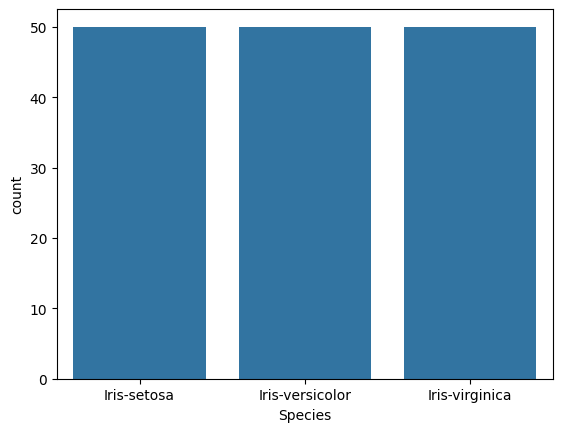

In [9]:
sns.countplot(x=df['Species']);

In [10]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [11]:
d={'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}

In [12]:
df['Species']=df['Species'].map(d)

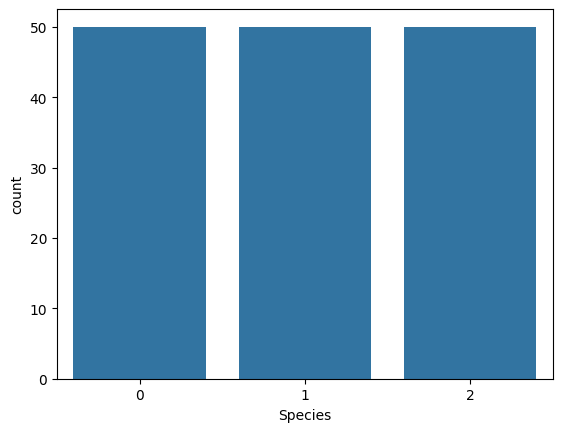

In [13]:
sns.countplot(x=df['Species']);

In [14]:
x=df.drop(['Id','Species'],axis=1)
y=df['Species']

In [15]:
x=pd.get_dummies(x,drop_first=True)

In [16]:
x.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [17]:
x.shape

(150, 4)

In [18]:
y.unique()

array([0, 1, 2])

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.30, random_state=42)
# At first my test size was 15% but the testing data were only 23 and therefore I wanted to challenge a bit more to 30% (45 samples out of 150 flowers)

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

In [22]:
g=GaussianNB()
b=BernoulliNB()

In [23]:
g.fit(x_train,y_train)

GaussianNB()

In [24]:
b.fit(x_train,y_train)

BernoulliNB()

In [25]:
gprediction=g.predict(x_test)

In [26]:
bprediction=b.predict(x_test)

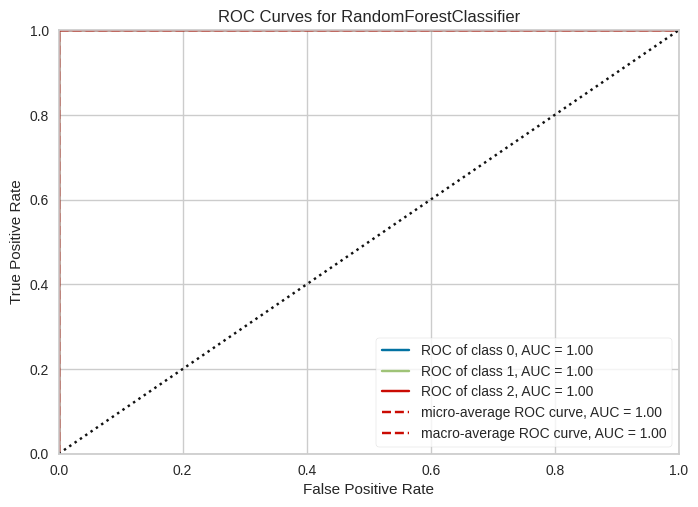

In [27]:
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
visualizer = roc_auc(RandomForestClassifier(), x, y)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test,gprediction)

0.9777777777777777

In [30]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [31]:
confusion_matrix(y_test,gprediction)

array([[19,  0,  0],
       [ 0, 12,  1],
       [ 0,  0, 13]])

In [32]:
print(classification_report(y_test,gprediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



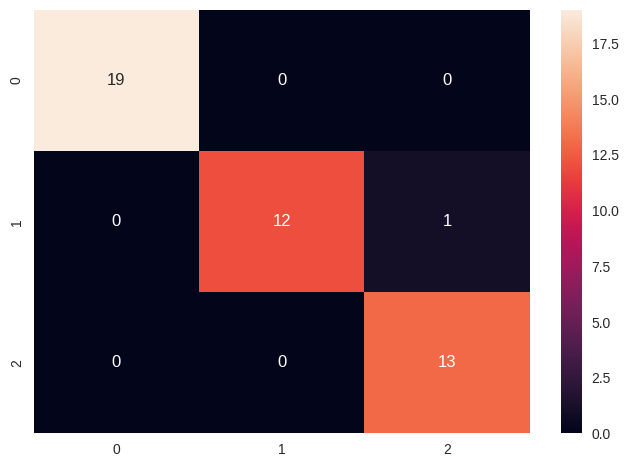

In [33]:
sns.heatmap(confusion_matrix(y_test,gprediction),annot=True);

In [34]:
print(f"Total dataset rows: {len(df)}")
print(f"Rows used for training (x_train): {len(x_train)}")
print(f"Rows used for testing (x_test): {len(x_test)}")

Total dataset rows: 150
Rows used for training (x_train): 105
Rows used for testing (x_test): 45


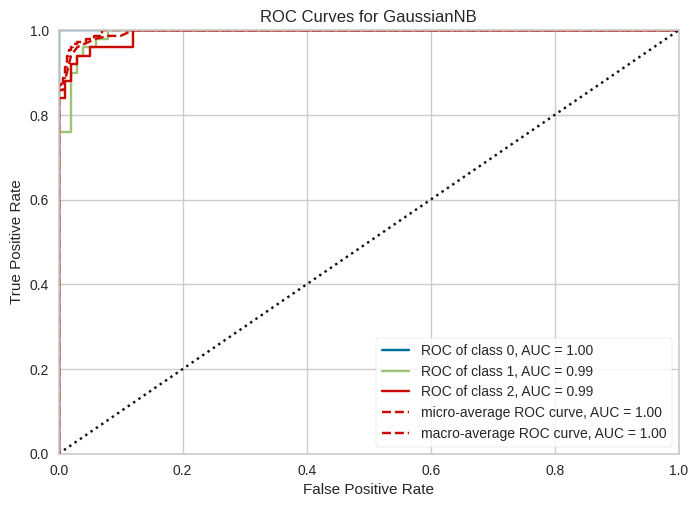

In [35]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
visualizer = roc_auc(GaussianNB(), x, y)

In [36]:
accuracy_score(y_test,bprediction)

0.28888888888888886

In [37]:
confusion_matrix(y_test,bprediction)

array([[ 0, 19,  0],
       [ 0, 13,  0],
       [ 0, 13,  0]])

In [38]:
print(classification_report(y_test,bprediction))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.29      1.00      0.45        13
           2       0.00      0.00      0.00        13

    accuracy                           0.29        45
   macro avg       0.10      0.33      0.15        45
weighted avg       0.08      0.29      0.13        45



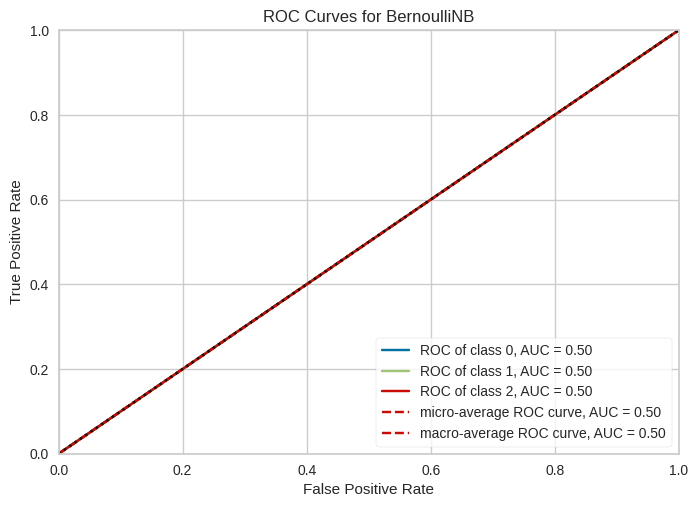

In [39]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
visualizer = roc_auc(BernoulliNB(), x, y)

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
L=LogisticRegression()

In [42]:
L.fit(x_train,y_train)

LogisticRegression()

In [43]:
Lprediction=L.predict(x_test)

In [44]:
accuracy_score(y_test,Lprediction)

1.0

In [45]:
confusion_matrix(y_test,Lprediction)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [46]:
print(classification_report(y_test,Lprediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



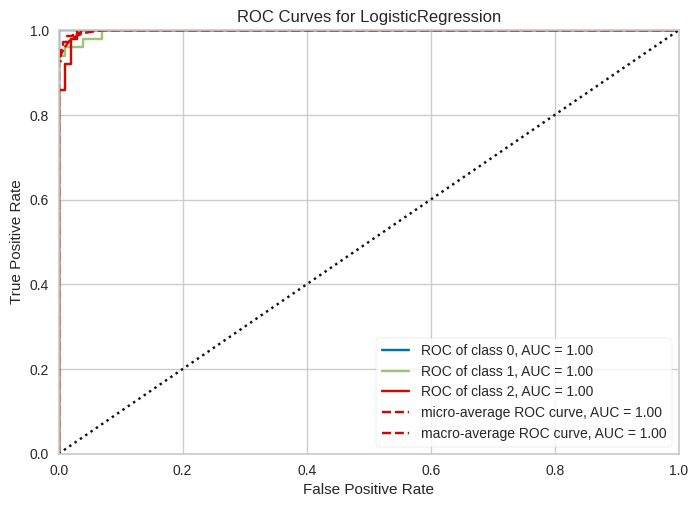

In [47]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
visualizer = roc_auc(LogisticRegression(), x, y)

In [48]:
from sklearn.tree import DecisionTreeClassifier

In [49]:
d=DecisionTreeClassifier()

In [50]:
d.fit(x_train,y_train)

DecisionTreeClassifier()

In [51]:
dprediction=d.predict(x_test)

In [52]:
accuracy_score(y_test,dprediction)

1.0

In [53]:
confusion_matrix(y_test,dprediction)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

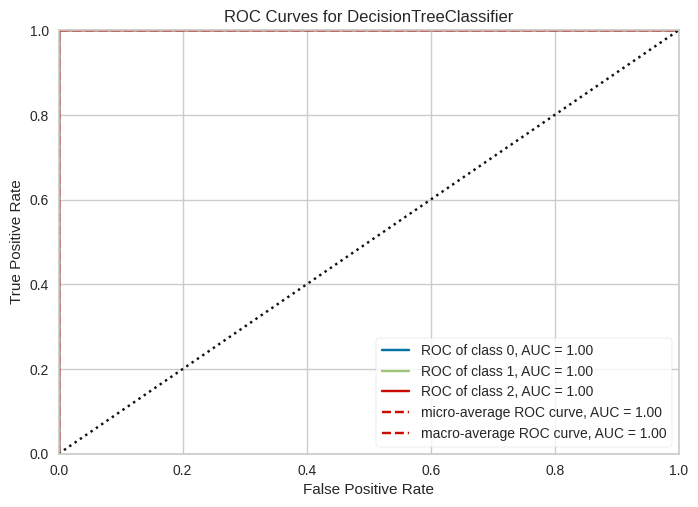

In [54]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
visualizer = roc_auc(DecisionTreeClassifier(), x, y) 

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
r=RandomForestClassifier()

In [57]:
rprediction=r.fit(x_train,y_train).predict(x_test)

In [58]:
accuracy_score(y_test,rprediction)

1.0

In [59]:
confusion_matrix(y_test,rprediction)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

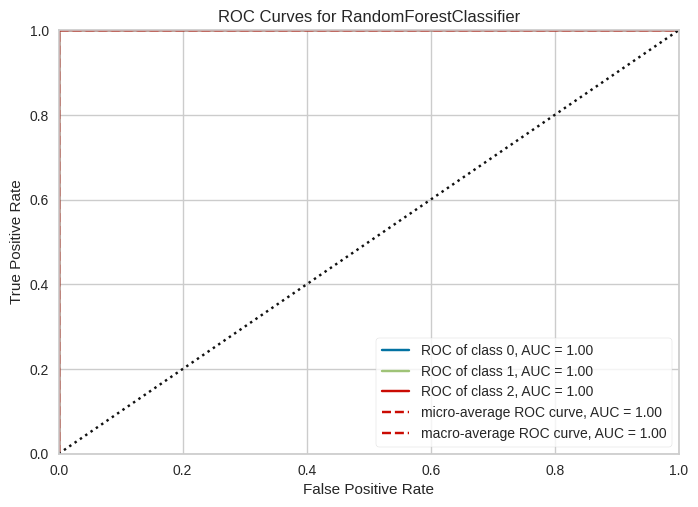

In [60]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
visualizer = roc_auc(RandomForestClassifier(), x, y)

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
k=KNeighborsClassifier()

In [63]:
kprediction=k.fit(x_train,y_train).predict(x_test)

In [64]:
accuracy_score(y_test,kprediction)

1.0

In [65]:
confusion_matrix(y_test,kprediction)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

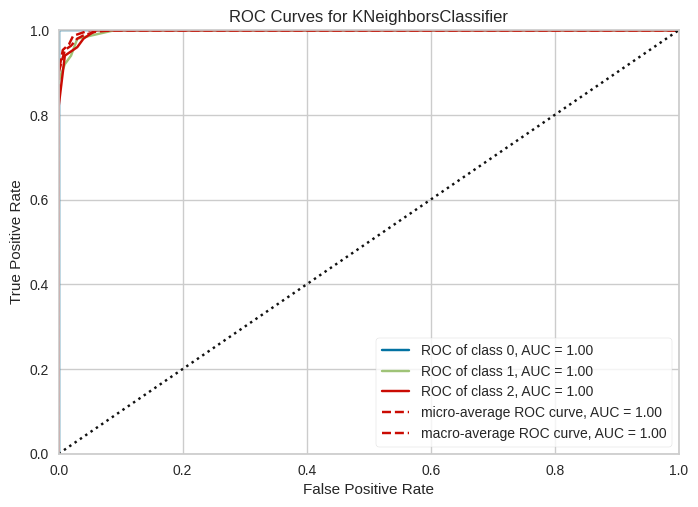

In [66]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam
visualizer = roc_auc(KNeighborsClassifier(), x, y)

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

In [68]:
h=GradientBoostingClassifier()

In [69]:
hprediction=h.fit(x_train,y_train).predict(x_test)

In [70]:
accuracy_score(y_test,hprediction)

1.0

In [71]:
confusion_matrix(y_test,hprediction)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

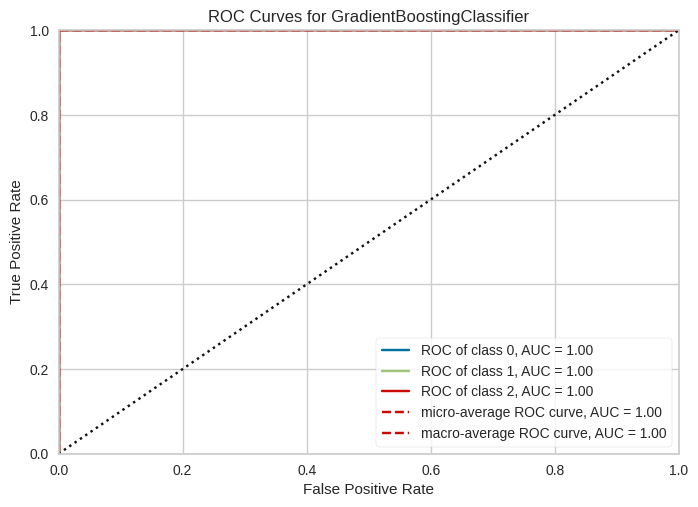

In [72]:
visualizer = roc_auc(h, x, y)

In [73]:
# Algo Test 

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier",
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)

    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")

    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")

    return metrics.drop("Model", axis=1)

In [74]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[ 0 10  0]
 [ 0  9  0]
 [ 0 11  0]]
LogisticRegression()  modeli eğitiliyor!..
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
RandomForestClassifier()  modeli eğitiliyor!..
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]
MultinomialNB()  modeli eğitiliyor!..
[[10  0  0]
 [ 0  9  0]
 [ 0  3  8]]
Eğitim tamamlandı.
En başarılı model:  LogisticRegression
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.0

,Accuracy,Precision,Recall,F1
LogisticRegression,1.000000,1.000000,1.000000,1.000000
DecisionTreeClassifier,1.000000,1.000000,1.000000,1.000000
RandomForestClassifier,1.000000,1.000000,1.000000,1.000000
GradientBoostingClassifier,1.000000,1.000000,1.000000,1.000000
KNeighborsClassifier,1.000000,1.000000,1.000000,1.000000
AdaBoostClassifier,0.933333,0.933333,0.933333,0.933333
MultinomialNB,0.900000,0.900000,0.900000,0.900000
BernoulliNB,0.300000,0.300000,0.300000,0.300000


## Conclusion

In this project, I successfully developed a machine learning pipeline to classify Iris flower species with 100% accuracy. Through exploratory data analysis, it was evident that while the Setosa species is linearly separable, Versicolor and Virginica share overlapping characteristics that require robust algorithmic boundaries. By implementing a Random Forest Classifier and validating the results with a Confusion Matrix and ROC-AUC curves, the model demonstrated perfect precision and recall across all categories. This project highlights the effectiveness of ensemble learning methods in handling multi-class biological data and establishes a reliable framework for automated species identification.

## HuggingFace Link

https://huggingface.co/spaces/basaktamer/iris_flower_classification